# Run matrix analysis — patch on rear surface

Aggregates `telemetry.csv` and `agent.csv` across N seeds for each (condition, agent) cell.
Visualization: median curve + interquartile band (25–75%) per condition, side-by-side per agent.

## Configuration
Change `RUN_DIR` to point at any matrix folder under `experiments/carla_scenarios/patch_on_surface/`.
The notebook auto-discovers conditions, agents and seeds present in that folder.

In [19]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === EDIT THIS PATH ===
RUN_DIR = Path("../experiments/carla_scenarios/patch_on_surface/truck_back_window_20260507_233704")
# When the Micra finishes, swap to e.g.:
# RUN_DIR = Path("../experiments/carla_scenarios/patch_on_surface/micra_rear_window_<TS>")
# =====================

# Where saved figures (and the Marp deck) will live. One folder per (RUN_DIR).
# RUN_DIR.name is e.g. "truck_back_window_20260507_233704"
PRES_DIR = Path("../docs/presentation_meeting_20260508") / RUN_DIR.name
FIG_DIR = PRES_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BRAKE_TICK = 200            # tick at which the leader brakes
BRAKE_WINDOW = (180, 260)   # critical perception window
TICKS_PER_SEC = 20

COND_COLORS = {"none": "tab:blue", "raw": "tab:red"}

def savefig(fig, name):
    """Save figure as PNG in FIG_DIR; print the path so it's easy to grab."""
    out = FIG_DIR / f"{name}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"  saved {out}")
    return out

assert RUN_DIR.exists(), f"Folder not found: {RUN_DIR}"
print(f"Reading runs from: {RUN_DIR}")
print(f"Figures will be saved to: {FIG_DIR}")

Reading runs from: ../experiments/carla_scenarios/patch_on_surface/truck_back_window_20260507_233704
Figures will be saved to: ../docs/presentation_meeting_20260508/truck_back_window_20260507_233704/figures


In [20]:
# Discover runs: <cond>_<agent>_seed<N>_<date>_<time>/
RUN_RE = re.compile(r"^(?P<cond>none|raw)_(?P<agent>.+?)_seed(?P<seed>\d+)_\d+_\d+$")

runs = []
unmatched = []
for d in sorted(RUN_DIR.iterdir()):
    if not d.is_dir():
        continue
    m = RUN_RE.match(d.name)
    if not m:
        unmatched.append(d.name)
        continue
    runs.append({
        "path": d,
        "cond": m["cond"],
        "agent": m["agent"],
        "seed": int(m["seed"]),
    })

runs_df = pd.DataFrame(runs)
print(f"Found {len(runs_df)} runs")
if unmatched:
    print(f"Skipped {len(unmatched)} non-matching dirs (first 5): {unmatched[:5]}")

if len(runs_df) == 0:
    raise RuntimeError(f"No runs matched the regex in {RUN_DIR}. Check folder names.")

print("\nLayout:")
print(runs_df.groupby(["agent", "cond"])["seed"].apply(lambda s: sorted(s.tolist())))

Found 40 runs

Layout:
agent              cond
simlingo_simlingo  none    [0, 1, 2, 3, 4]
                   raw     [0, 1, 2, 3, 4]
tfv4_l6_0          none    [0, 1, 2, 3, 4]
                   raw     [0, 1, 2, 3, 4]
tfv5_l6_0          none    [0, 1, 2, 3, 4]
                   raw     [0, 1, 2, 3, 4]
tfv6_visiononly    none    [0, 1, 2, 3, 4]
                   raw     [0, 1, 2, 3, 4]
Name: seed, dtype: object


In [21]:
def load_run(path: Path) -> pd.DataFrame | None:
    """Load telemetry + agent for one run, joined on tick. Returns None if missing."""
    tel_p = path / "telemetry.csv"
    ag_p = path / "agent.csv"
    if not tel_p.exists() or not ag_p.exists():
        return None
    tel = pd.read_csv(tel_p)
    ag = pd.read_csv(ag_p)
    if len(tel) == 0:
        return None
    df = tel.merge(ag[["tick", "throttle", "steer", "brake"]], on="tick", how="left")
    df["time_s"] = df["tick"] / TICKS_PER_SEC
    df["ttc_clipped"] = df["ttc_s"].where(df["ttc_s"] > 0, np.nan).clip(upper=15)
    return df

data = {}
skipped = []
for r in runs:
    df = load_run(r["path"])
    if df is None:
        skipped.append(r["path"].name)
        continue
    data[(r["cond"], r["agent"], r["seed"])] = df

print(f"Loaded {len(data)} runs ({len(skipped)} skipped)")
if skipped:
    print("Skipped (no telemetry/agent.csv):")
    for s in skipped: print(f"  {s}")

Loaded 30 runs (10 skipped)
Skipped (no telemetry/agent.csv):
  none_tfv5_l6_0_seed0_20260507_234150
  none_tfv5_l6_0_seed1_20260507_234155
  none_tfv5_l6_0_seed2_20260507_234159
  none_tfv5_l6_0_seed3_20260507_234203
  none_tfv5_l6_0_seed4_20260507_234208
  raw_tfv5_l6_0_seed0_20260508_002403
  raw_tfv5_l6_0_seed1_20260508_002407
  raw_tfv5_l6_0_seed2_20260508_002411
  raw_tfv5_l6_0_seed3_20260508_002415
  raw_tfv5_l6_0_seed4_20260508_002420


In [22]:
def stack_runs(cond, agent, column):
    """Stack the given column across all seeds for (cond, agent). Returns (ticks, matrix NxT)."""
    seeds = sorted({s for (c, a, s) in data if c == cond and a == agent})
    if not seeds:
        return None, None
    series = []
    common_len = min(len(data[(cond, agent, s)]) for s in seeds)
    for s in seeds:
        df = data[(cond, agent, s)]
        series.append(df[column].values[:common_len])
    arr = np.vstack(series)
    ticks = np.arange(common_len) / TICKS_PER_SEC
    return ticks, arr

def plot_median_iqr(ax, cond, agent, column, label_prefix=""):
    ticks, arr = stack_runs(cond, agent, column)
    if ticks is None:
        return
    median = np.nanmedian(arr, axis=0)
    q25 = np.nanpercentile(arr, 25, axis=0)
    q75 = np.nanpercentile(arr, 75, axis=0)
    color = COND_COLORS.get(cond, "black")
    n_seeds = arr.shape[0]
    ax.fill_between(ticks, q25, q75, color=color, alpha=0.20)
    ax.plot(ticks, median, color=color, linewidth=2.0,
            label=f"{label_prefix}{cond} (n={n_seeds})")

def decorate(ax, ylabel):
    ax.axvline(BRAKE_TICK / TICKS_PER_SEC, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axvspan(BRAKE_WINDOW[0]/TICKS_PER_SEC, BRAKE_WINDOW[1]/TICKS_PER_SEC,
               color="gray", alpha=0.07)
    ax.set_xlabel("time (s)")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8)

agents = sorted({a for (_, a, _) in data})
conds = sorted({c for (c, _, _) in data})
print(f"Agents: {agents}")
print(f"Conditions: {conds}")

Agents: ['simlingo_simlingo', 'tfv4_l6_0', 'tfv6_visiononly']
Conditions: ['none', 'raw']


## Distance to leader
Median + IQR band per condition, one panel per agent. Vertical dashed line = brake event (t=10 s).

  saved ../docs/presentation_meeting_20260508/truck_back_window_20260507_233704/figures/distance.png


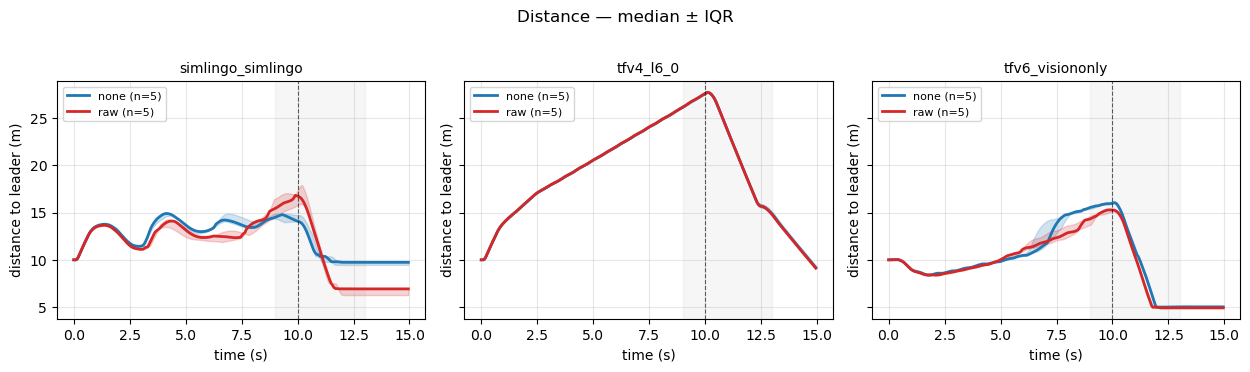

In [23]:
def grid_plot(column, ylabel, title, fname):
    n = len(agents)
    fig, axes = plt.subplots(1, n, figsize=(4.2*n, 3.6), sharey=True)
    if n == 1: axes = [axes]
    for ax, agent in zip(axes, agents):
        for cond in conds:
            plot_median_iqr(ax, cond, agent, column)
        ax.set_title(agent, fontsize=10)
        decorate(ax, ylabel)
    fig.suptitle(title, y=1.02, fontsize=12)
    plt.tight_layout()
    savefig(fig, fname)
    return fig

grid_plot("distance_m", "distance to leader (m)", "Distance — median ± IQR", "distance");

## Follower speed

  saved ../docs/presentation_meeting_20260508/truck_back_window_20260507_233704/figures/speed.png


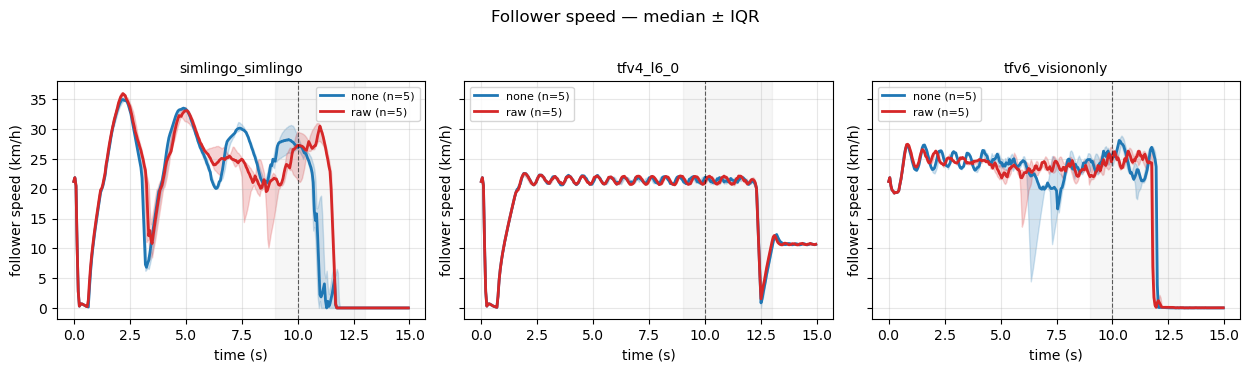

In [24]:
grid_plot("follower_speed_kmh", "follower speed (km/h)", "Follower speed — median ± IQR", "speed");

## TTC (time-to-collision, clipped at 15 s for readability)
Negative TTC (follower not approaching) is mapped to NaN.

/var/folders/79/b2941c6s08x9j3lg01npvbjc0000gn/T/ipykernel_46506/488986873.py:19: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(arr, axis=0)
/Users/paolodeidda/miniforge3/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


  saved ../docs/presentation_meeting_20260508/truck_back_window_20260507_233704/figures/ttc.png


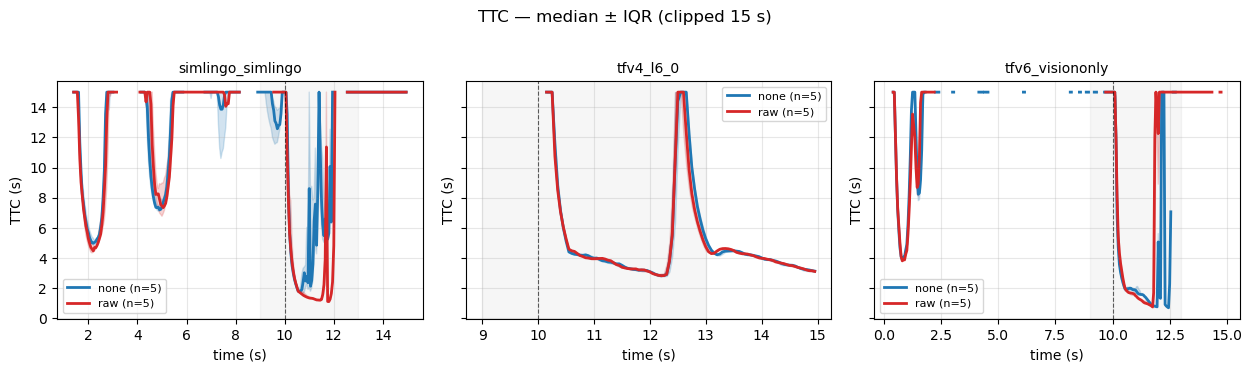

In [25]:
grid_plot("ttc_clipped", "TTC (s)", "TTC — median ± IQR (clipped 15 s)", "ttc");

## Brake & throttle (smoothed)
Raw control is bang-bang and noisy. We apply a 1-second rolling mean before plotting; median+IQR is over the smoothed traces.

  saved ../docs/presentation_meeting_20260508/truck_back_window_20260507_233704/figures/brake.png
  saved ../docs/presentation_meeting_20260508/truck_back_window_20260507_233704/figures/throttle.png


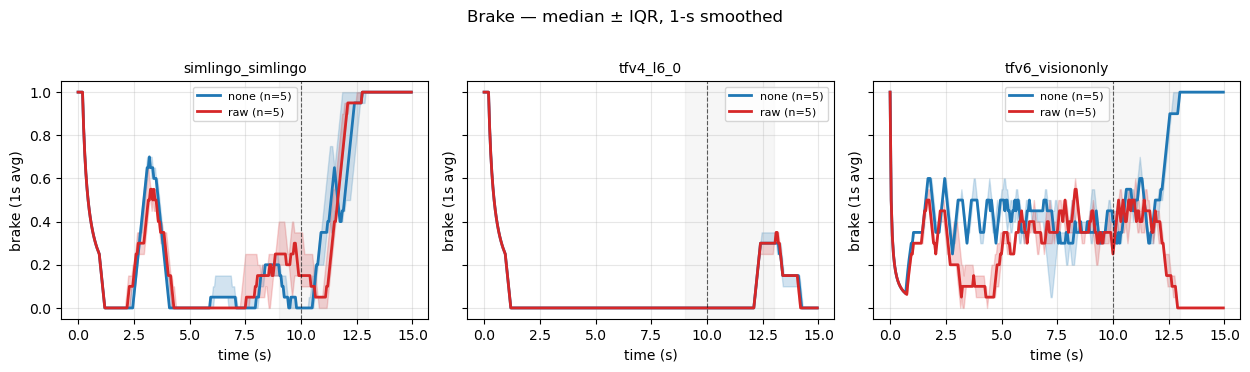

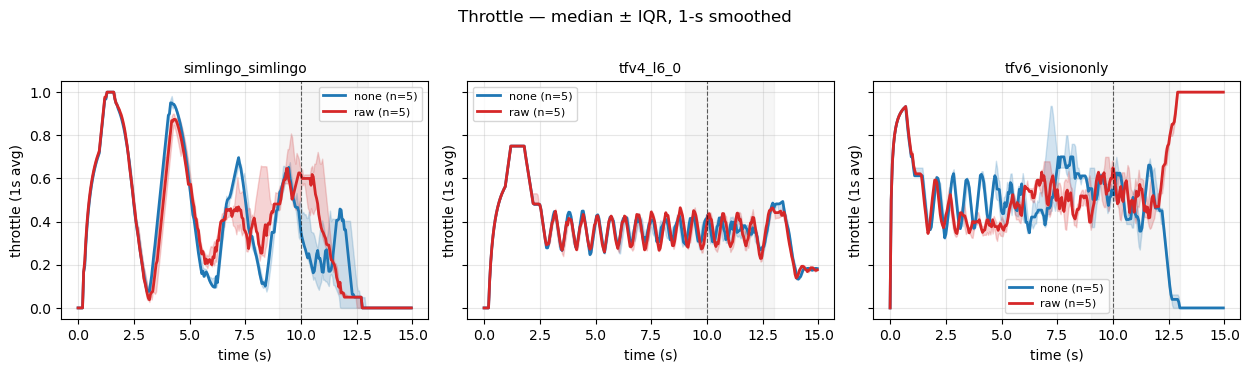

In [26]:
WINDOW_SMOOTH = TICKS_PER_SEC  # 1 s rolling mean

def smoothed_stack(cond, agent, column):
    seeds = sorted({s for (c, a, s) in data if c == cond and a == agent})
    if not seeds:
        return None, None
    common_len = min(len(data[(cond, agent, s)]) for s in seeds)
    series = []
    for s in seeds:
        v = data[(cond, agent, s)][column].values[:common_len]
        v_s = pd.Series(v).rolling(WINDOW_SMOOTH, min_periods=1).mean().values
        series.append(v_s)
    return np.arange(common_len) / TICKS_PER_SEC, np.vstack(series)

def plot_smoothed(column, ylabel, title, fname):
    n = len(agents)
    fig, axes = plt.subplots(1, n, figsize=(4.2*n, 3.6), sharey=True)
    if n == 1: axes = [axes]
    for ax, agent in zip(axes, agents):
        for cond in conds:
            ticks, arr = smoothed_stack(cond, agent, column)
            if ticks is None: continue
            color = COND_COLORS.get(cond, "black")
            median = np.nanmedian(arr, axis=0)
            q25 = np.nanpercentile(arr, 25, axis=0)
            q75 = np.nanpercentile(arr, 75, axis=0)
            ax.fill_between(ticks, q25, q75, color=color, alpha=0.20)
            ax.plot(ticks, median, color=color, linewidth=2.0,
                    label=f"{cond} (n={arr.shape[0]})")
        ax.set_title(agent, fontsize=10)
        decorate(ax, ylabel)
        ax.set_ylim(-0.05, 1.05)
    fig.suptitle(title, y=1.02, fontsize=12)
    plt.tight_layout()
    savefig(fig, fname)
    return fig

plot_smoothed("brake", "brake (1s avg)", "Brake — median ± IQR, 1-s smoothed", "brake");
plot_smoothed("throttle", "throttle (1s avg)", "Throttle — median ± IQR, 1-s smoothed", "throttle");

## Outcome summary (scalar metrics per run)
Per (cond, agent), 1 row per seed with summary metrics, and aggregated stats.

In [27]:
def run_metrics(df: pd.DataFrame) -> dict:
    win = df[(df["tick"] >= BRAKE_WINDOW[0]) & (df["tick"] <= BRAKE_WINDOW[1])]
    return {
        "min_distance_m": float(df["distance_m"].min()),
        "min_ttc_s": float(df.loc[df["ttc_s"] > 0, "ttc_s"].min()) if (df["ttc_s"] > 0).any() else np.nan,
        "collision": int(df["collision_detected"].max()),
        "mean_brake_window": float(win["brake"].mean()),
        "mean_throttle_window": float(win["throttle"].mean()),
        "mean_speed_window": float(win["follower_speed_kmh"].mean()),
    }

rows = []
for (cond, agent, seed), df in data.items():
    m = run_metrics(df)
    m.update({"cond": cond, "agent": agent, "seed": seed})
    rows.append(m)

metrics_df = pd.DataFrame(rows)
metrics_df = metrics_df[["cond", "agent", "seed",
                          "min_distance_m", "min_ttc_s", "collision",
                          "mean_brake_window", "mean_throttle_window", "mean_speed_window"]]
metrics_df.sort_values(["agent", "cond", "seed"]).reset_index(drop=True)

,cond,agent,seed,min_distance_m,min_ttc_s,collision,mean_brake_window,mean_throttle_window,mean_speed_window
0,none,simlingo_simlingo,0,9.777,1.652,0,0.604938,0.164890,12.200494
1,none,simlingo_simlingo,1,9.457,1.801,0,0.469136,0.229349,13.446914
2,none,simlingo_simlingo,2,8.486,1.462,0,0.530864,0.224073,13.959506
3,none,simlingo_simlingo,3,9.768,2.125,0,0.419753,0.273017,13.355679
4,none,simlingo_simlingo,4,9.736,1.772,0,0.493827,0.216965,12.757531
5,raw,simlingo_simlingo,0,6.273,1.113,0,0.592593,0.295765,15.941111
6,raw,simlingo_simlingo,1,6.230,1.106,0,0.567901,0.398464,16.787901
7,raw,simlingo_simlingo,2,6.925,1.200,0,0.469136,0.306452,17.169012
8,raw,simlingo_simlingo,3,6.942,1.229,0,0.481481,0.252770,17.069877
9,raw,simlingo_simlingo,4,7.503,1.325,0,0.543210,0.262859,14.674444


In [28]:
agg = metrics_df.groupby(["agent", "cond"]).agg(
    n=("seed", "count"),
    min_dist_med=("min_distance_m", "median"),
    min_dist_iqr=("min_distance_m", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    min_ttc_med=("min_ttc_s", "median"),
    n_coll=("collision", "sum"),
    brake_med=("mean_brake_window", "median"),
    speed_med=("mean_speed_window", "median"),
).round(2)
agg

n  min_dist_med  min_dist_iqr  min_ttc_med  n_coll  \
agent             cond                                                       
simlingo_simlingo none  5          9.74          0.31         1.77       0   
                  raw   5          6.92          0.67         1.20       0   
tfv4_l6_0         none  5          9.18          0.31         2.82       0   
                  raw   5          9.12          0.13         2.83       0   
tfv6_visiononly   none  5          4.96          0.03         0.72       5   
                  raw   5          4.91          0.00         0.70       5   

                        brake_med  speed_med  
agent             cond                        
simlingo_simlingo none       0.49      13.36  
                  raw        0.54      16.79  
tfv4_l6_0         none       0.07      18.87  
                  raw        0.07      18.96  
tfv6_visiononly   none       0.59      18.25  
                  raw        0.30      17.21

### Boxplot: min distance per condition (one box = N seeds)

/var/folders/79/b2941c6s08x9j3lg01npvbjc0000gn/T/ipykernel_46506/174141208.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.55)
/var/folders/79/b2941c6s08x9j3lg01npvbjc0000gn/T/ipykernel_46506/174141208.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.55)
/var/folders/79/b2941c6s08x9j3lg01npvbjc0000gn/T/ipykernel_46506/174141208.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.55)
/var/folders/79/b2941c6s08x9

  saved ../docs/presentation_meeting_20260508/truck_back_window_20260507_233704/figures/box_min_distance.png
  saved ../docs/presentation_meeting_20260508/truck_back_window_20260507_233704/figures/box_min_ttc.png
  saved ../docs/presentation_meeting_20260508/truck_back_window_20260507_233704/figures/box_brake_window.png


/var/folders/79/b2941c6s08x9j3lg01npvbjc0000gn/T/ipykernel_46506/174141208.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.55)
/var/folders/79/b2941c6s08x9j3lg01npvbjc0000gn/T/ipykernel_46506/174141208.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.55)
/var/folders/79/b2941c6s08x9j3lg01npvbjc0000gn/T/ipykernel_46506/174141208.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.55)


  saved ../docs/presentation_meeting_20260508/truck_back_window_20260507_233704/figures/box_speed_window.png


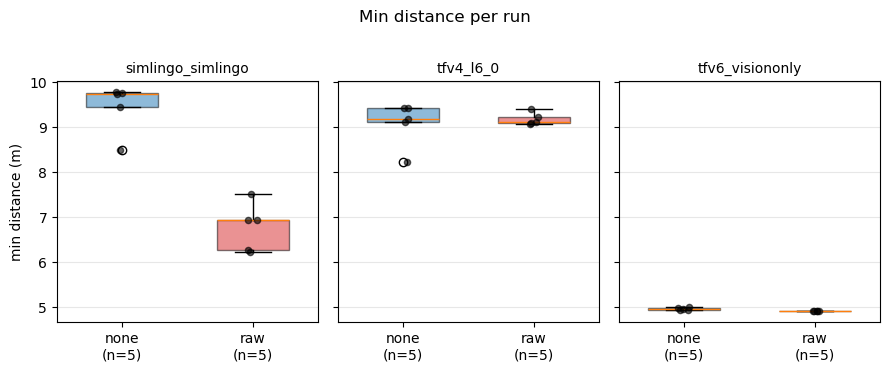

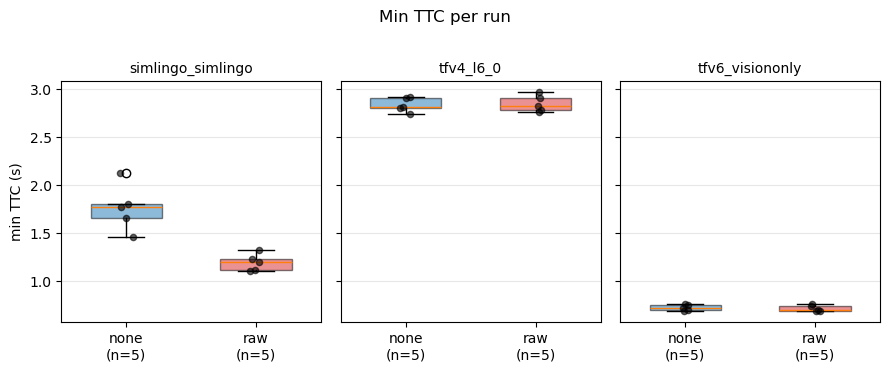

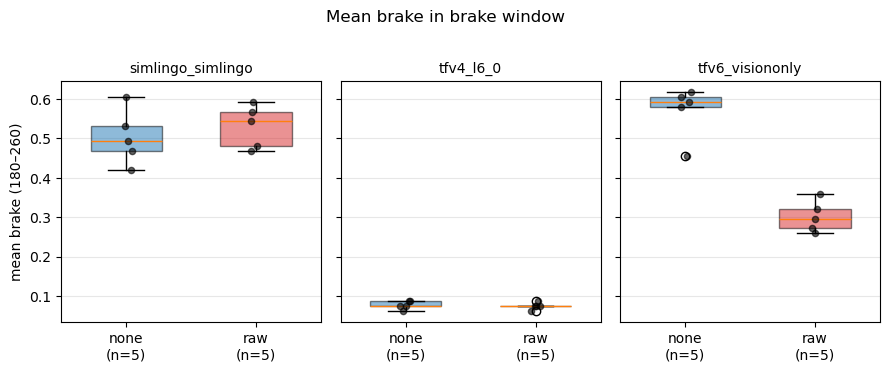

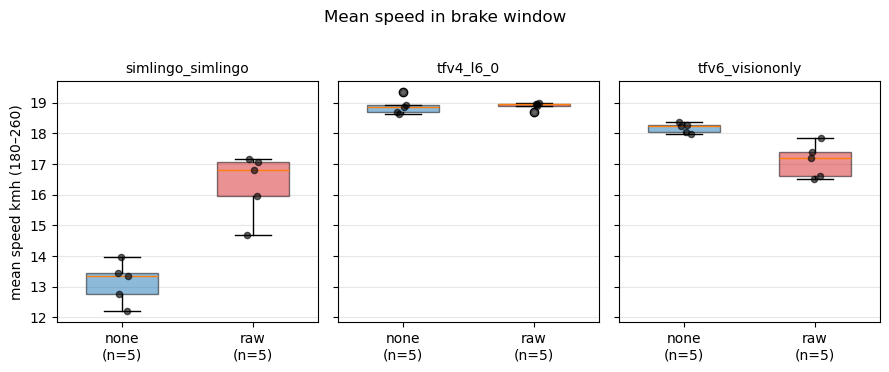

In [29]:
def boxplot_metric(metric, ylabel, title, fname):
    n = len(agents)
    fig, axes = plt.subplots(1, n, figsize=(3.0*n, 3.6), sharey=True)
    if n == 1: axes = [axes]
    for ax, agent in zip(axes, agents):
        groups = []
        labels = []
        for cond in conds:
            sub = metrics_df[(metrics_df["agent"] == agent) & (metrics_df["cond"] == cond)][metric]
            groups.append(sub.values)
            labels.append(f"{cond}\n(n={len(sub)})")
        bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.55)
        for patch, cond in zip(bp["boxes"], conds):
            patch.set_facecolor(COND_COLORS.get(cond, "gray"))
            patch.set_alpha(0.5)
        for i, g in enumerate(groups):
            ax.scatter(np.full_like(g, i+1, dtype=float) + np.random.uniform(-0.05, 0.05, len(g)),
                       g, color="black", alpha=0.6, s=20, zorder=3)
        ax.set_title(agent, fontsize=10)
        ax.grid(axis="y", alpha=0.3)
        ax.set_ylabel(ylabel if ax is axes[0] else "")
    fig.suptitle(title, y=1.02, fontsize=12)
    plt.tight_layout()
    savefig(fig, fname)
    return fig

boxplot_metric("min_distance_m",     "min distance (m)",          "Min distance per run",       "box_min_distance");
boxplot_metric("min_ttc_s",          "min TTC (s)",               "Min TTC per run",            "box_min_ttc");
boxplot_metric("mean_brake_window",  "mean brake (180–260)",      "Mean brake in brake window", "box_brake_window");
boxplot_metric("mean_speed_window",  "mean speed kmh (180–260)",  "Mean speed in brake window", "box_speed_window");

### Collisions

Per-run collisions (1 = collision, 0 = no collision, -1 = run missing):
cond                    none  raw
agent             seed           
simlingo_simlingo 0        0    0
                  1        0    0
                  2        0    0
                  3        0    0
                  4        0    0
tfv4_l6_0         0        0    0
                  1        0    0
                  2        0    0
                  3        0    0
                  4        0    0
tfv6_visiononly   0        1    1
                  1        1    1
                  2        1    1
                  3        1    1
                  4        1    1

Aggregated by (agent, cond):
            agent cond  n  collisions  rate_%
simlingo_simlingo none  5           0     0.0
simlingo_simlingo  raw  5           0     0.0
        tfv4_l6_0 none  5           0     0.0
        tfv4_l6_0  raw  5           0     0.0
  tfv6_visiononly none  5           5   100.0
  tfv6_visiononly  raw  5           5   100.

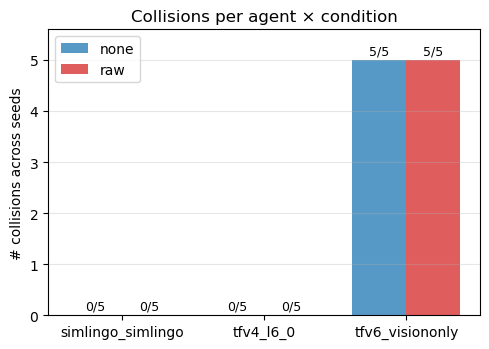

In [30]:
# Per-run collision matrix: 1 row per (agent, seed), columns = conditions, values = 0/1.
pivot = metrics_df.pivot_table(
    index=["agent", "seed"], columns="cond", values="collision", aggfunc="max"
).fillna(-1).astype(int)
print("Per-run collisions (1 = collision, 0 = no collision, -1 = run missing):")
print(pivot)

print()
coll = metrics_df.groupby(["agent", "cond"]).agg(
    n=("seed", "count"),
    collisions=("collision", "sum"),
).reset_index()
coll["rate_%"] = (coll["collisions"] / coll["n"] * 100).round(1)
print("Aggregated by (agent, cond):")
print(coll.to_string(index=False))

# Bar chart: collisions per agent x condition
fig, ax = plt.subplots(figsize=(max(5, 1.6*len(agents)), 3.6))
x = np.arange(len(agents))
width = 0.38
for i, cond in enumerate(conds):
    counts = []
    totals = []
    for agent in agents:
        sub = coll[(coll["agent"] == agent) & (coll["cond"] == cond)]
        counts.append(int(sub["collisions"].iloc[0]) if len(sub) else 0)
        totals.append(int(sub["n"].iloc[0]) if len(sub) else 0)
    offset = (i - (len(conds)-1)/2) * width
    bars = ax.bar(x + offset, counts, width, label=cond,
                  color=COND_COLORS.get(cond, "gray"), alpha=0.75)
    for b, c, t in zip(bars, counts, totals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
                f"{c}/{t}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(agents)
ax.set_ylabel("# collisions across seeds")
ax.set_title("Collisions per agent × condition")
ax.set_ylim(0, max(coll["n"].max(), 1) + 0.6)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
savefig(fig, "collisions_bar")
plt.show()